In [1]:
# CELL 1 — Imports & Style Setup
# Sets up all libraries and applies a dark professional chart theme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor': '#1A1D2E',
    'axes.edgecolor': '#2E3250',
    'axes.labelcolor': '#C8CAFF',
    'xtick.color': '#8B8FA8',
    'ytick.color': '#8B8FA8',
    'grid.color': '#2E3250',
    'grid.alpha': 0.6,
    'text.color': '#E0E2FF',
    'font.family': 'DejaVu Sans',
    'axes.titlepad': 14,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

COLORS = ['#6C8EFF', '#FF6B9D', '#FFD166', '#06D6A0', '#FF9A3C']
print("✅ Libraries loaded. Style configured.")

✅ Libraries loaded. Style configured.


In [2]:
# CELL 2 — Generate Synthetic Retail Dataset
# Creates 525 records with seasonality, trend, and noise. Saves to CSV.
np.random.seed(42)

dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='W')
products  = ['Rice 5kg', 'Cooking Oil', 'Sugar 1kg', 'Shampoo 200ml', 'Detergent 1kg']
base_sales = [420, 280, 360, 190, 310]
base_price = [250, 180, 55, 220, 140]

rows = []
for i, product in enumerate(products):
    for date in dates:
        seasonal = 1 + 0.35 * np.sin(2 * np.pi * (date.month - 3) / 12)
        trend = 1 + 0.0015 * (date - dates[0]).days / 7
        noise = np.random.normal(0, 25)
        sales = max(10, int(base_sales[i] * seasonal * trend + noise))
        stock = np.random.randint(80, 400)
        price = round(base_price[i] * (1 + np.random.uniform(-0.05, 0.05)), 2)
        revenue = round(sales * price, 2)
        rows.append({
            'date': date, 'product': product, 'sales_units': sales,
            'stock_units': stock, 'unit_price': price, 'revenue': revenue,
            'month': date.month, 'week': date.isocalendar()[1],
            'quarter': date.quarter, 'year': date.year
        })

df = pd.DataFrame(rows)
df.to_csv('retail_sales.csv', index=False)
print(f"✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📅 Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"🛍️  Products: {df['product'].nunique()}")
df.head(8)

✅ Dataset created: 525 rows × 10 columns
📅 Date range: 2023-01-01 → 2024-12-29
🛍️  Products: 5


,date,product,sales_units,stock_units,unit_price,revenue,month,week,quarter,year
0,2023-01-01,Rice 5kg,305,186,256.99,78381.95,1,52,1,2023
1,2023-01-08,Rice 5kg,289,100,241.40,69764.60,1,1,1,2023
2,2023-01-15,Rice 5kg,300,231,253.77,76131.00,1,2,1,2023
3,2023-01-22,Rice 5kg,319,388,261.75,83498.25,1,3,1,2023
4,2023-01-29,Rice 5kg,282,271,262.31,73971.42,1,4,1,2023
5,2023-02-05,Rice 5kg,362,240,245.11,88729.82,2,5,1,2023
6,2023-02-12,Rice 5kg,284,128,250.62,71176.08,2,6,1,2023
7,2023-02-19,Rice 5kg,373,249,238.67,89023.91,2,7,1,2023


In [3]:
# CELL 3 — Data Overview & Stats
# Quick sanity check: shape, nulls, column list, and descriptive stats.
print("="*52)
print("  DATA OVERVIEW")
print("="*52)
print(f"\n🔢 Shape: {df.shape}")
print(f"❌ Null values: {df.isnull().sum().sum()}")
print(f"🗂️  Columns: {list(df.columns)}")
print("\n📊 Summary Statistics:")
df[['sales_units', 'stock_units', 'unit_price', 'revenue']].describe().round(2)

  DATA OVERVIEW

🔢 Shape: (525, 10)
❌ Null values: 0
🗂️  Columns: ['date', 'product', 'sales_units', 'stock_units', 'unit_price', 'revenue', 'month', 'week', 'quarter', 'year']

📊 Summary Statistics:


,sales_units,stock_units,unit_price,revenue
count,525.00,525.00,525.00,525.00
mean,335.68,234.42,169.02,55988.65
std,122.27,95.17,68.41,34654.28
min,99.00,80.00,52.26,11317.35
25%,240.00,154.00,136.54,30918.16
50%,317.00,232.00,180.85,48460.88
75%,421.00,313.00,225.08,66816.06
max,650.00,399.00,262.31,168239.50


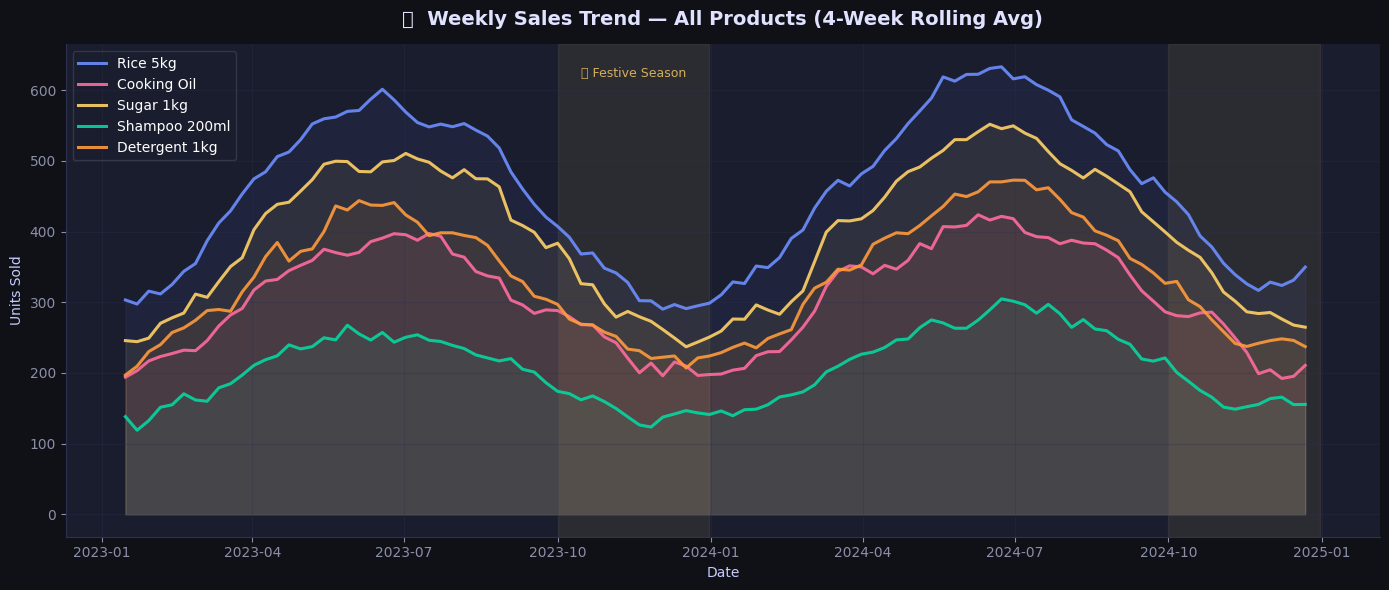

💾 Saved: chart1_sales_trend.png


In [4]:
# CELL 4 — EDA Chart 1: Sales Trend Over Time
# Line chart showing all 5 products with rolling average smoothing.
fig, ax = plt.subplots(figsize=(14, 6))

for i, product in enumerate(products):
    prod_df = df[df['product'] == product].sort_values('date')
    smoothed = prod_df['sales_units'].rolling(4, center=True).mean()
    ax.plot(prod_df['date'], smoothed, label=product, color=COLORS[i], linewidth=2.2, alpha=0.9)
    ax.fill_between(prod_df['date'], smoothed, alpha=0.07, color=COLORS[i])

ax.set_title('📈  Weekly Sales Trend — All Products (4-Week Rolling Avg)', color='#E0E2FF', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold')
ax.legend(framealpha=0.15, labelcolor='white', loc='upper left')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.axvspan(pd.Timestamp('2023-10-01'), pd.Timestamp('2023-12-31'), alpha=0.08, color='#FFD166')
ax.axvspan(pd.Timestamp('2024-10-01'), pd.Timestamp('2024-12-31'), alpha=0.08, color='#FFD166')
ax.text(pd.Timestamp('2023-10-15'), ax.get_ylim()[1]*0.93, '🎉 Festive Season', color='#FFD166', fontsize=9, alpha=0.8)

plt.tight_layout()
plt.savefig('chart1_sales_trend.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("💾 Saved: chart1_sales_trend.png")

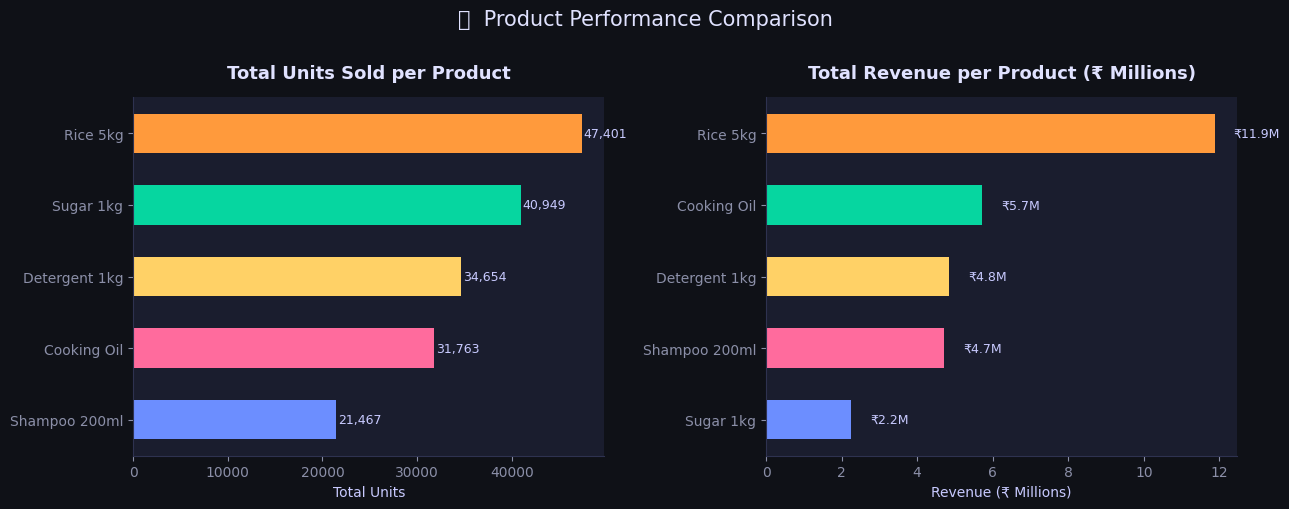

💾 Saved: chart2_product_comparison.png


In [5]:
# CELL 5 — EDA Chart 2: Product & Revenue Comparison
# Side-by-side bar charts comparing units sold and total revenue.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

total_sales = df.groupby('product')['sales_units'].sum().sort_values(ascending=True)
bars1 = ax1.barh(total_sales.index, total_sales.values, color=COLORS[:len(products)], height=0.55, edgecolor='none')
ax1.set_title('Total Units Sold per Product')
ax1.set_xlabel('Total Units')
for bar, val in zip(bars1, total_sales.values):
    ax1.text(val + 200, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', color='#C8CAFF', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

total_rev = df.groupby('product')['revenue'].sum().sort_values(ascending=True)
bars2 = ax2.barh(total_rev.index, total_rev.values / 1e6, color=COLORS[:len(products)], height=0.55, edgecolor='none')
ax2.set_title('Total Revenue per Product (₹ Millions)')
ax2.set_xlabel('Revenue (₹ Millions)')
for bar, val in zip(bars2, total_rev.values):
    ax2.text(val/1e6 + 0.5, bar.get_y() + bar.get_height()/2, f'₹{val/1e6:.1f}M', va='center', color='#C8CAFF', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('📊  Product Performance Comparison', fontsize=15, color='#E0E2FF', y=1.01)
plt.tight_layout()
plt.savefig('chart2_product_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("💾 Saved: chart2_product_comparison.png")

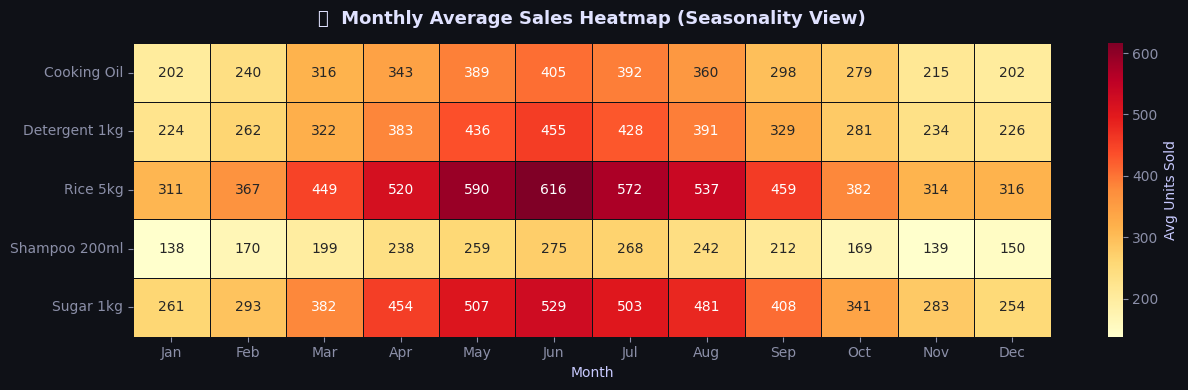

💾 Saved: chart3_heatmap.png


In [6]:
# CELL 6 — EDA Chart 3: Monthly Seasonality Heatmap
# Heatmap revealing which months are high/low sales for each product.
monthly_pivot = df.groupby(['product', 'month'])['sales_units'].mean().unstack()
monthly_pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(monthly_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='#0F1117', ax=ax, cbar_kws={'label': 'Avg Units Sold'})
ax.set_title('🗓️  Monthly Average Sales Heatmap (Seasonality View)', fontsize=13, pad=14)
ax.set_xlabel('Month')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('chart3_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("💾 Saved: chart3_heatmap.png")

In [7]:
# CELL 7 — Feature Engineering
# Adds time-based features: week number, sin/cos encoding, festive flag.
df['week_num']   = (df['date'] - df['date'].min()).dt.days // 7
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
df['is_festive'] = df['month'].isin([10, 11, 12]).astype(int)
df['is_q1']      = (df['quarter'] == 1).astype(int)

print("✅ Features engineered:")
print("  week_num   → continuous time index (trend)")
print("  month_sin  → captures monthly cyclical pattern (sin component)")
print("  month_cos  → captures monthly cyclical pattern (cos component)")
print("  is_festive → 1 for Oct/Nov/Dec, 0 otherwise")
print("  is_q1      → 1 for January–March (typically lower sales)")
df[['date','product','sales_units','week_num','month_sin','month_cos','is_festive']].head(6)

✅ Features engineered:
  week_num   → continuous time index (trend)
  month_sin  → captures monthly cyclical pattern (sin component)
  month_cos  → captures monthly cyclical pattern (cos component)
  is_festive → 1 for Oct/Nov/Dec, 0 otherwise
  is_q1      → 1 for January–March (typically lower sales)


,date,product,sales_units,week_num,month_sin,month_cos,is_festive
0,2023-01-01,Rice 5kg,305,0,0.500000,0.866025,0
1,2023-01-08,Rice 5kg,289,1,0.500000,0.866025,0
2,2023-01-15,Rice 5kg,300,2,0.500000,0.866025,0
3,2023-01-22,Rice 5kg,319,3,0.500000,0.866025,0
4,2023-01-29,Rice 5kg,282,4,0.500000,0.866025,0
5,2023-02-05,Rice 5kg,362,5,0.866025,0.500000,0


In [8]:
# CELL 8 — Train Forecasting Models (All 5 Products)
# Trains Linear Regression per product. Prints MAE and R² score.
FEATURES = ['week_num', 'month_sin', 'month_cos', 'is_festive', 'is_q1']
model_results = {}

print("Training models...\n")
print(f"{'Product':<22} {'MAE':>8} {'R² Score':>10}")
print("-" * 44)

for product in products:
    prod_df = df[df['product'] == product].sort_values('date').reset_index(drop=True)
    X = prod_df[FEATURES]
    y = prod_df['sales_units']

    split = int(len(prod_df) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    print(f"{product:<22} {mae:>8.1f} {r2:>10.3f}")

    model_results[product] = {
        'model': model, 'test_dates': prod_df['date'].iloc[split:],
        'y_test': y_test.values, 'y_pred': y_pred, 'mae': mae, 'r2': r2
    }

print("\n✅ All models trained.")

Training models...

Product                     MAE   R² Score
--------------------------------------------
Rice 5kg                   19.0      0.923
Cooking Oil                25.8      0.792
Sugar 1kg                  20.1      0.904
Shampoo 200ml              19.4      0.727
Detergent 1kg              21.6      0.836

✅ All models trained.


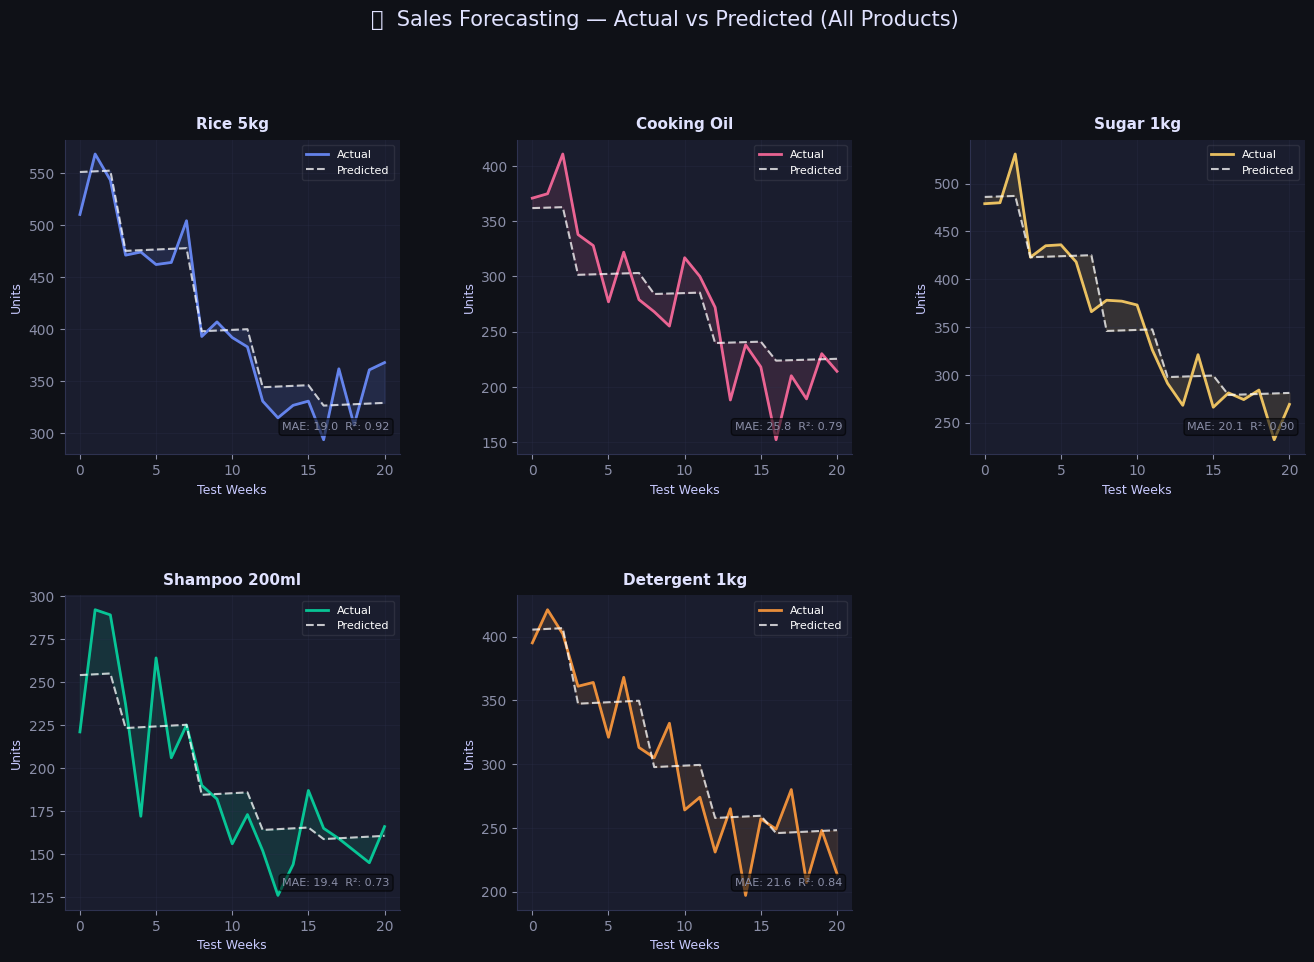

💾 Saved: chart4_forecast_results.png


In [9]:
# CELL 9 — Forecast Dashboard: Actual vs Predicted
# 2x3 grid showing actual vs predicted sales for every product.
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0F1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

for idx, (product, res) in enumerate(model_results.items()):
    row, col = divmod(idx, 3)
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor('#1A1D2E')

    ax.plot(range(len(res['y_test'])), res['y_test'], color=COLORS[idx], linewidth=2, label='Actual', alpha=0.9)
    ax.plot(range(len(res['y_pred'])), res['y_pred'], color='white', linewidth=1.5, linestyle='--', label='Predicted', alpha=0.75)
    ax.fill_between(range(len(res['y_test'])), res['y_test'], res['y_pred'], alpha=0.12, color=COLORS[idx])

    ax.set_title(f"{product}", color='#E0E2FF', fontsize=11, pad=8)
    ax.set_xlabel('Test Weeks', fontsize=9)
    ax.set_ylabel('Units', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.1, labelcolor='white')
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(0.97, 0.07, f"MAE: {res['mae']:.1f}  R²: {res['r2']:.2f}",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='#8B8FA8',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0F1117', alpha=0.6))

fig.add_subplot(gs[1, 2]).set_visible(False)
fig.suptitle('🔮  Sales Forecasting — Actual vs Predicted (All Products)', fontsize=15, color='#E0E2FF', y=1.01)
plt.savefig('chart4_forecast_results.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("💾 Saved: chart4_forecast_results.png")

In [10]:
# CELL 10 — Inventory Optimization Logic
# Calculates safety stock, reorder point, and reorder status per product.
LEAD_TIME_WEEKS = 2
SERVICE_LEVEL_Z = 1.65

inv_df = df.groupby('product').agg(
    avg_weekly_sales=('sales_units', 'mean'),
    std_weekly_sales=('sales_units', 'std'),
    avg_stock=('stock_units', 'mean'),
    min_stock=('stock_units', 'min'),
    max_stock=('stock_units', 'max'),
).reset_index().round(1)

inv_df['safety_stock']  = (SERVICE_LEVEL_Z * inv_df['std_weekly_sales'] * np.sqrt(LEAD_TIME_WEEKS)).round(0).astype(int)
inv_df['reorder_point'] = (inv_df['avg_weekly_sales'] * LEAD_TIME_WEEKS + inv_df['safety_stock']).round(0).astype(int)
inv_df['eoq_approx']    = (inv_df['avg_weekly_sales'] * 4).round(0).astype(int)
inv_df['status'] = inv_df.apply(
    lambda r: '🔴 REORDER NOW' if r['avg_stock'] < r['reorder_point']
              else ('🟡 MONITOR' if r['avg_stock'] < r['reorder_point'] * 1.3 else '🟢 SUFFICIENT'), axis=1)

print("="*75)
print(f"{'Product':<22} {'Avg Sales':>10} {'Safety Stk':>11} {'Reorder Pt':>11} {'Avg Stock':>10} {'Status'}")
print("-"*75)
for _, row in inv_df.iterrows():
    print(f"{row['product']:<22} {row['avg_weekly_sales']:>10.0f} {row['safety_stock']:>11} "
          f"{row['reorder_point']:>11} {row['avg_stock']:>10.0f}  {row['status']}")
print("="*75)

inv_df.to_csv('inventory_report.csv', index=False)
print("\n💾 Saved: inventory_report.csv")

Product                 Avg Sales  Safety Stk  Reorder Pt  Avg Stock Status
---------------------------------------------------------------------------
Cooking Oil                   302         183         788        229  🔴 REORDER NOW
Detergent 1kg                 330         204         864        233  🔴 REORDER NOW
Rice 5kg                      451         262        1165        242  🔴 REORDER NOW
Shampoo 200ml                 204         130         539        222  🔴 REORDER NOW
Sugar 1kg                     390         242        1022        246  🔴 REORDER NOW

💾 Saved: inventory_report.csv


In [ ]:
# CELL 11 — Inventory Chart
# Bar chart (stock vs thresholds) + donut chart (health status).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(inv_df))
w = 0.28

b1 = ax1.bar(x - w, inv_df['avg_stock'],      w, label='Avg Current Stock', color='#6C8EFF', alpha=0.9)
b2 = ax1.bar(x,     inv_df['reorder_point'],   w, label='Reorder Point',     color='#FF6B9D', alpha=0.9)
b3 = ax1.bar(x + w, inv_df['safety_stock'],    w, label='Safety Stock',      color='#FFD166', alpha=0.9)

ax1.set_xticks(x)
ax1.set_xticklabels(inv_df['product'], rotation=15, ha='right', fontsize=9)
ax1.set_title('📦  Stock Levels vs Reorder Thresholds', color='#E0E2FF')
ax1.set_ylabel('Units')
ax1.legend(framealpha=0.15, labelcolor='white', fontsize=9)
ax1.grid(True, axis='y', alpha=0.25)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.axhline(y=inv_df['reorder_point'].mean(), color='#FF6B9D', linestyle=':', alpha=0.5, linewidth=1.2)

status_counts = inv_df['status'].value_counts()
raw_labels = status_counts.index.tolist()
clean_labels = [s.split(' ', 1)[1] if ' ' in s else s for s in raw_labels]
donut_colors = ['#FF6B9D' if 'REORDER' in s else '#FFD166' if 'MONITOR' in s else '#06D6A0' for s in raw_labels]

wedges, texts, autotexts = ax2.pie(
    status_counts.values, labels=clean_labels, autopct='%1.0f%%',
    colors=donut_colors, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='#0F1117', linewidth=2),
    textprops={'color': '#E0E2FF', 'fontsize': 10})
for at in autotexts:
    at.set_color('#0F1117')
    at.set_fontweight('bold')

ax2.set_title('🚦  Inventory Health Status', color='#E0E2FF')
plt.tight_layout()
plt.savefig('chart5_inventory.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("💾 Saved: chart5_inventory.png")

In [ ]:
# CELL 12 — Final Business Summary Report
# Prints a boxed summary of all key metrics and saved files.
total_rev_all = df['revenue'].sum()
best_product  = df.groupby('product')['revenue'].sum().idxmax()
weak_product  = df.groupby('product')['revenue'].sum().idxmin()
reorder_now   = inv_df[inv_df['status'].str.contains('REORDER')]['product'].tolist()
avg_model_mae = np.mean([v['mae'] for v in model_results.values()])
avg_model_r2  = np.mean([v['r2'] for v in model_results.values()])

print()
print("╔══════════════════════════════════════════════════════╗")
print("║   RETAIL SALES FORECASTING & INVENTORY REPORT       ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📦 Products Tracked     : {df['product'].nunique():<27}║")
print(f"║  📅 Analysis Period      : {str(df['date'].min().date())} → {str(df['date'].max().date())}  ║")
print(f"║  📊 Total Records        : {len(df):<27,}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  💰 Total Revenue        : ₹{total_rev_all:>22,.0f}  ║")
print(f"║  🏆 Top Product (Revenue): {best_product:<27}║")
print(f"║  📉 Weak Product         : {weak_product:<27}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  🤖 Avg Forecast MAE     : {avg_model_mae:<27.1f}║")
print(f"║  📈 Avg Model R² Score   : {avg_model_r2:<27.3f}║")
print("╠══════════════════════════════════════════════════════╣")
reorder_str = ', '.join(reorder_now) if reorder_now else 'None — All levels OK'
print(f"║  🔴 Reorder Required     : {reorder_str[:27]:<27}║")
print("╠══════════════════════════════════════════════════════╣")
print("║  📁 Files Saved:                                     ║")
print("║     retail_sales.csv  |  inventory_report.csv       ║")
print("║     chart1_sales_trend.png                          ║")
print("║     chart2_product_comparison.png                   ║")
print("║     chart3_heatmap.png                              ║")
print("║     chart4_forecast_results.png                     ║")
print("║     chart5_inventory.png                            ║")
print("╚══════════════════════════════════════════════════════╝")